#importing libraries numpy and pandas

In [31]:
import pandas as pd

In [32]:
import numpy as np

#initializing random numbers generator using seed

In [33]:
np.random.seed(42)


#setting the factors 

In [34]:
temperature = np.round(np.random.uniform(15, 40, 100), 1)

In [35]:
humidity = np.round(np.random.uniform(30, 100, 100), 1)

#probability

In [55]:
def rain_probability(humidity, temperature):
    w1 = 0.05   # weight for humidity
    w2 = -0.03  # weight for temperature (negative = higher temp reduces rain chance)
    b = -2      # bias term
    prob = 1 / (1 + np.exp(-(w1*humidity + w2*temperature + b)))
    return prob

In [56]:
rain = np.random.binomial(1, prob)

#view dataset

In [57]:
df = pd.DataFrame({
    "temperature": temperature,
    "humidity": humidity,
    "rain": rain
})

In [58]:
print(df.head(10)) 

   temperature  humidity  rain
0         24.4      32.2     0
1         38.8      74.5     1
2         33.3      52.0     0
3         30.0      65.6     0
4         18.9      93.5     1
5         18.9      47.5     1
6         16.5      58.7     1
7         36.7      82.9     1
8         30.0      46.0     1
9         32.7      35.4     0


In [59]:
df.to_csv("weather_dataset.csv", index=False)

#import functions to split dataset

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
from sklearn.linear_model import LogisticRegression

In [62]:
from sklearn.metrics import accuracy_score

#define features x and label y

In [63]:
X = df[["temperature", "humidity"]]

In [64]:
y = df["rain"]

#split dataset into training set and test set

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#splitted set

In [66]:
print(X_train, X_test, y_train, y_test)

    temperature  humidity
55         38.0      46.9
88         37.2      67.1
26         20.0      87.3
42         15.9      64.8
69         39.7      71.4
..          ...       ...
60         24.7      55.7
71         20.0      31.2
14         19.5      74.3
92         34.0      93.0
51         34.4      46.8

[80 rows x 2 columns]     temperature  humidity
83         16.6      91.4
53         37.4      64.3
70         34.3      77.4
45         31.6      32.6
44         21.5      49.9
39         26.0      98.0
22         22.3      52.3
80         36.6      53.9
10         15.5      50.3
0          24.4      32.2
18         25.8      92.5
30         30.2      59.2
73         35.4      45.9
33         38.7      53.6
90         18.0      36.5
4          18.9      93.5
76         34.3      78.4
77         16.9      57.1
12         35.8      95.1
31         19.3      45.5 55    0
88    0
26    1
42    1
69    1
     ..
60    1
71    0
14    0
92    1
51    1
Name: rain, Length: 80, dtype: 

#call logistic regression for classification

In [67]:
model = LogisticRegression()

#fit the model on training set

In [68]:
model.fit(X_train, y_train)


LogisticRegression()

#model prediction on test set

In [69]:
y_pred = model.predict(X_test)

#plot data using matplotlib

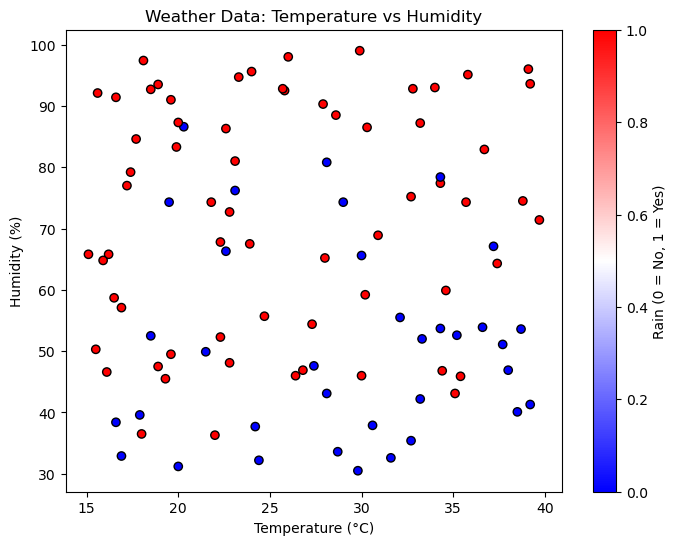

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['temperature'], df['humidity'], c=df['rain'], cmap='bwr', edgecolor='k')
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.title("Weather Data: Temperature vs Humidity")
plt.colorbar(label="Rain (0 = No, 1 = Yes)")
plt.show()

#evaluate accuracy of model

In [74]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.75
